In [2]:
import json
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv", header=0)

# df = pd.DataFrame(data)

print(df.head())

print(df.shape)
print(df.dtypes)



   customer_id  limit_bal  sex  education  marriage   age  pay_1  pay_2  \
0            1       1500  2.0        1.0       2.0  23.0    0.0    0.0   
1            2       8500  2.0        2.0       2.0  29.0    0.0    0.0   
2            3       1000  1.0        1.0       2.0  22.0    0.0    0.0   
3            4      10500  1.0        1.0       1.0  31.0    0.0    0.0   
4            5      10500  2.0        2.0       1.0  44.0    0.0    0.0   

   pay_3  pay_4  ...  bill_amt4  bill_amt5  bill_amt6  pay_amt1  pay_amt2  \
0    0.0    2.0  ...       1463      938.0      698.0        75       150   
1    0.0    0.0  ...       8364     8275.0     8425.0       300       400   
2    0.0    0.0  ...        933      772.0      794.0       150       150   
3    0.0    0.0  ...       7190     7229.0     7340.0       255       260   
4    0.0    0.0  ...       3558     3592.0     3496.0       180       155   

   pay_amt3  pay_amt4  pay_amt5  pay_amt6  default_oct  
0        86         0      50

In [4]:
# print(df["default_oct"].value_counts())
print(df["default_oct"].value_counts(normalize=True))
df.describe()

default_oct
no     0.778801
yes    0.221199
Name: proportion, dtype: float64


,customer_id,limit_bal,sex,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6
count,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,24001.000000,...,24001.000000,24001.000000,23819.000000,22790.000000,24001.000000,24001.000000,24001.000000,24001.000000,23819.000000,22790.000000
mean,12001.000000,8351.302029,1.604058,1.856839,1.551644,35.498438,-0.015874,-0.132119,-0.166201,-0.215824,...,2359.795592,2175.804383,2024.383559,1960.335981,281.079955,298.237073,263.109704,243.367943,238.731139,256.517069
std,6928.636241,6475.592450,0.489062,0.792152,0.522663,9.222021,1.123554,1.199237,1.196802,1.173350,...,3499.639871,3244.170936,3063.487512,3015.469078,846.819525,1215.481369,899.406651,782.138847,779.341974,861.106314
min,1.000000,500.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-3075.000000,-8500.000000,-4066.000000,-10452.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6001.000000,2500.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,130.000000,116.000000,90.000000,62.000000,49.000000,41.000000,19.000000,15.000000,12.000000,6.000000
50%,12001.000000,7000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,1007.000000,953.000000,906.000000,855.500000,105.000000,100.000000,90.000000,75.000000,75.000000,75.000000
75%,18001.000000,12000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,3015.000000,2752.000000,2510.500000,2466.000000,250.000000,250.000000,227.000000,200.000000,200.000000,200.000000
max,24001.000000,50000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,83204.000000,44579.000000,46358.000000,48083.000000,43677.000000,84212.000000,44802.000000,31050.000000,21326.000000,26433.000000


In [5]:
print (df.isna().sum())

customer_id       0
limit_bal         0
sex               0
education         0
marriage          0
age               0
pay_1             0
pay_2             0
pay_3             0
pay_4             0
pay_5           182
pay_6          1211
bill_amt1         0
bill_amt2         0
bill_amt3         0
bill_amt4         0
bill_amt5       182
bill_amt6      1211
pay_amt1          0
pay_amt2          0
pay_amt3          0
pay_amt4          0
pay_amt5        182
pay_amt6       1211
default_oct       0
dtype: int64


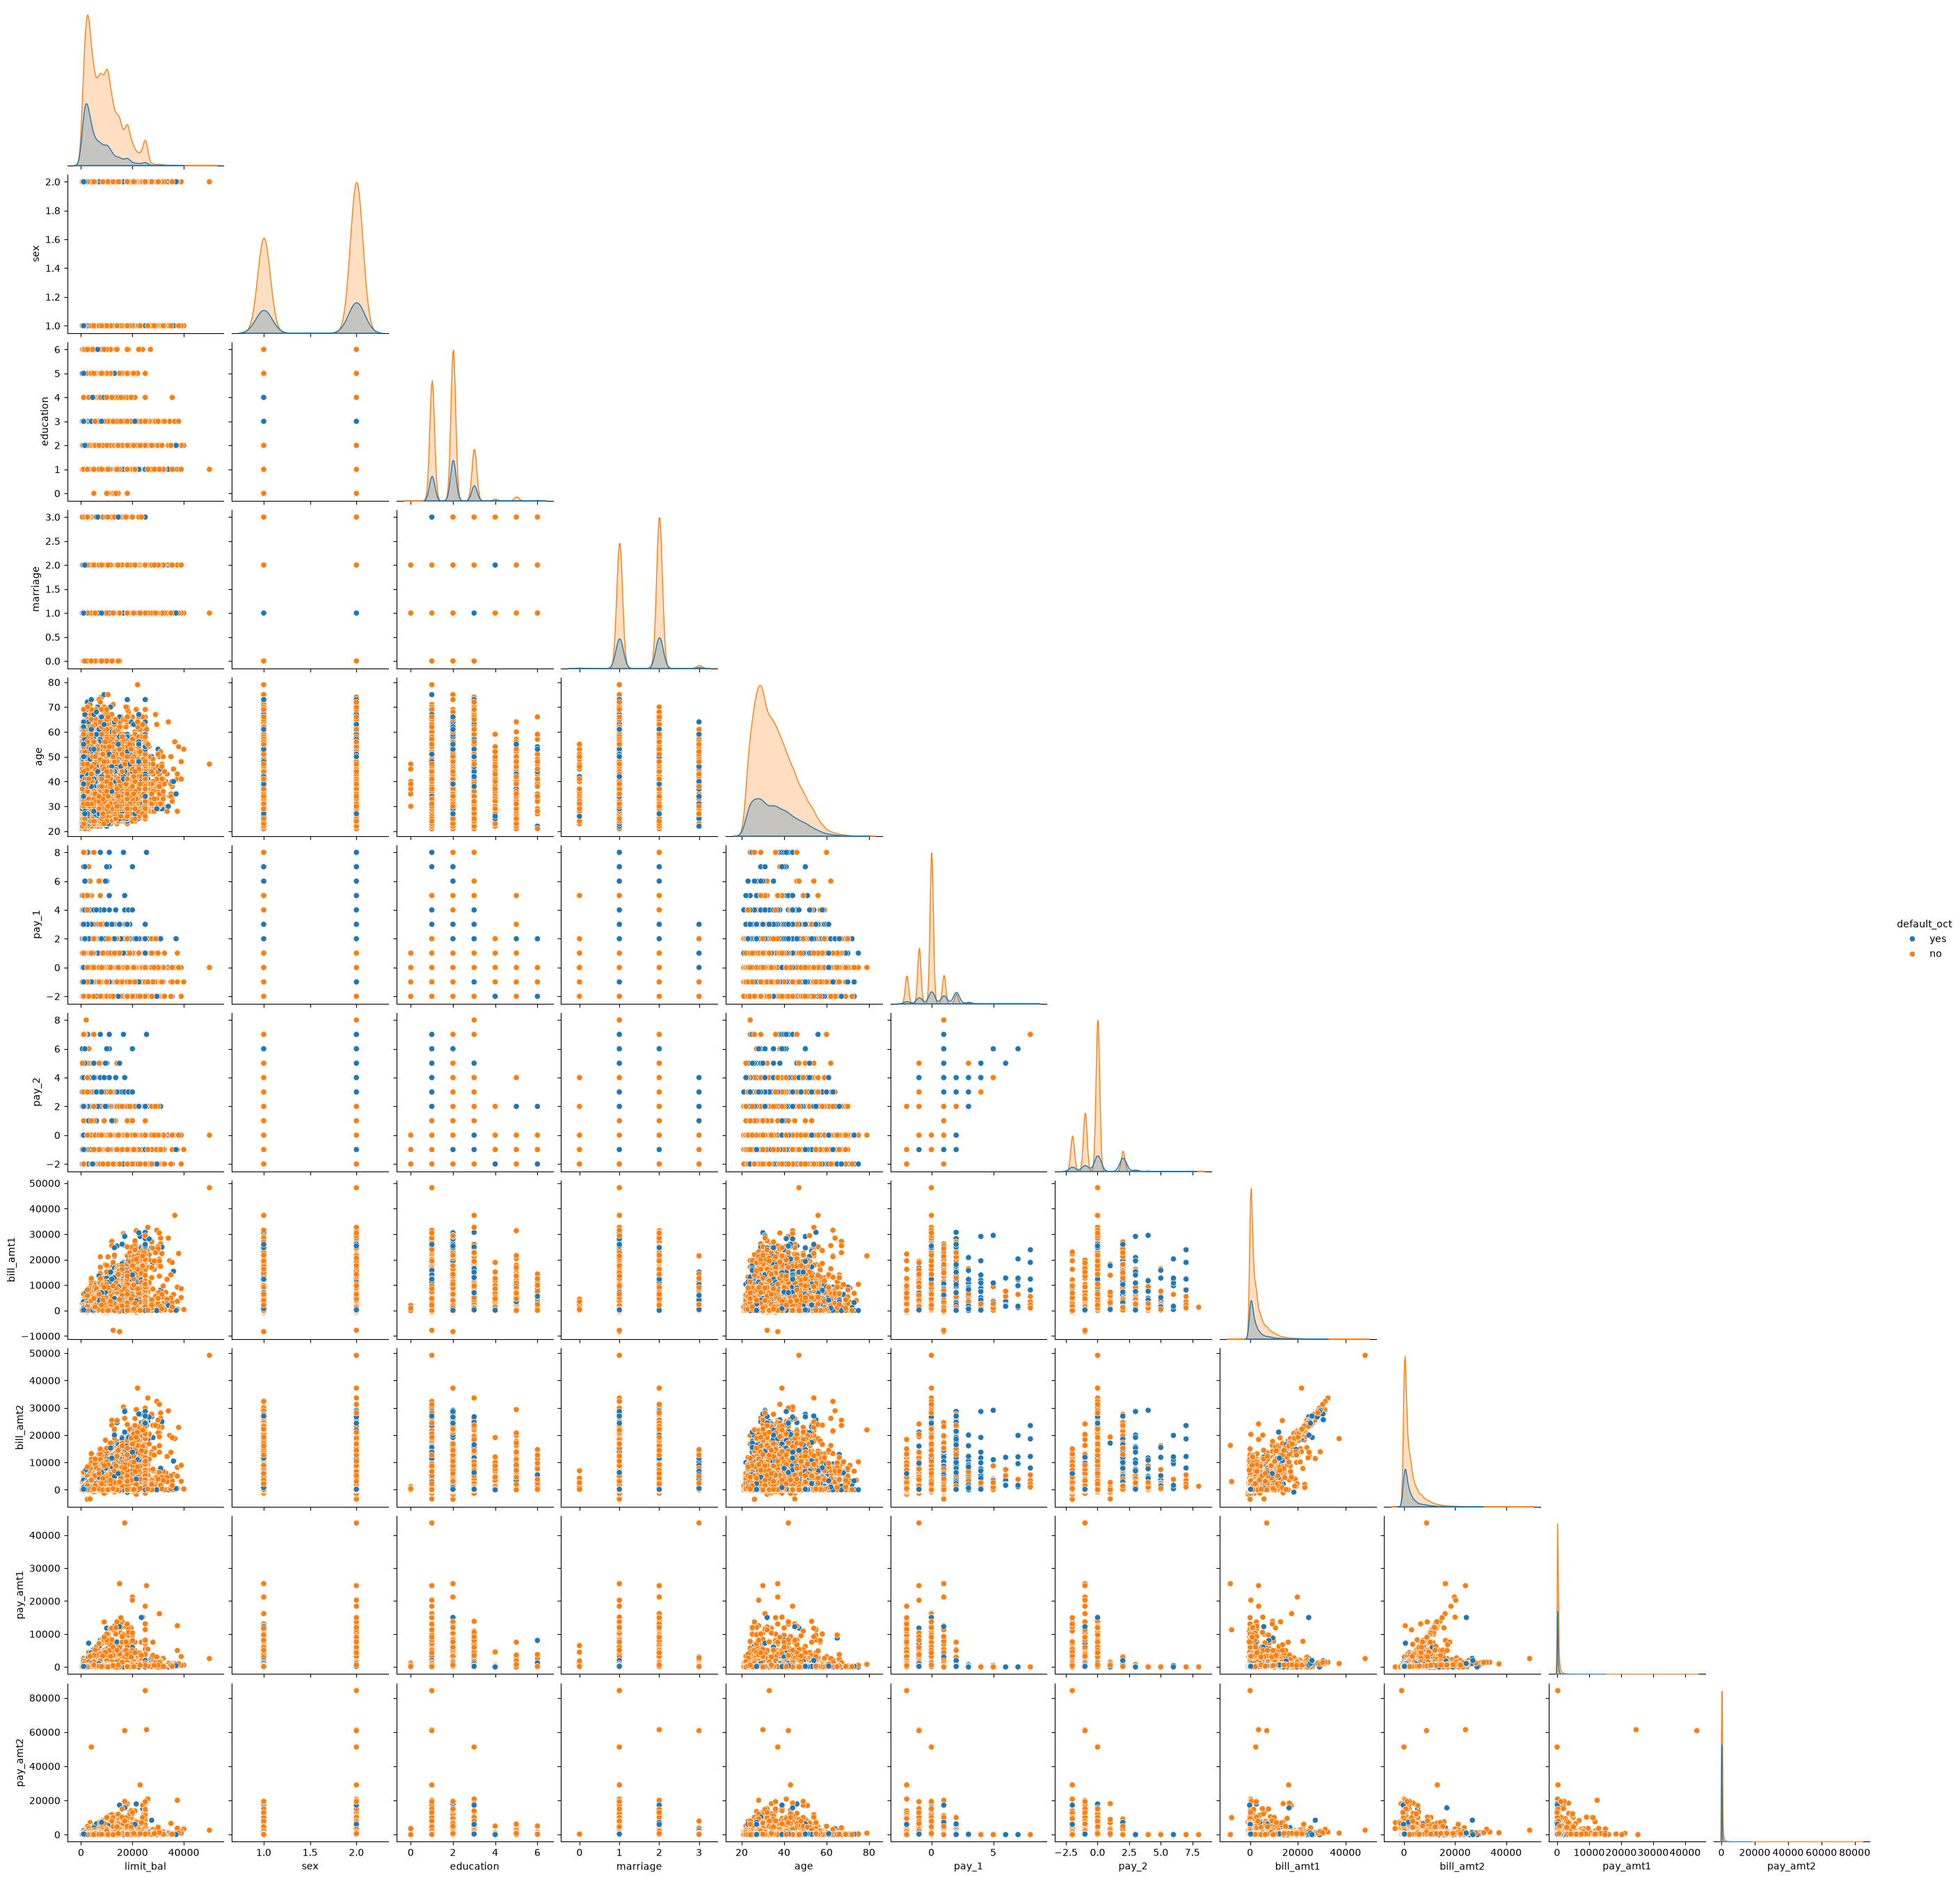

In [3]:
import seaborn as sns

selected_cols = [
    'limit_bal', 'sex', 'education', 'marriage', 'age',
    'pay_1', 'pay_2',
    'bill_amt1', 'bill_amt2',
    'pay_amt1', 'pay_amt2',
    'default_oct'
]

sns.pairplot(
    df[selected_cols],
    vars=['limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_1', 'pay_2', 'bill_amt1', 'bill_amt2', 'pay_amt1', 'pay_amt2'],
    hue='default_oct',
    corner=True
)


In [4]:
df.shape

(24001, 25)

In [6]:
# Check and drop duplicate rows
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print(f'Original rows: {before}')
print(f'Duplicate rows removed: {before - after}')

# Drop rows with any missing values
missing_before = df.isna().sum().sum()
df = df.dropna()
missing_after = df.isna().sum().sum()

print(f'Missing values removed: {missing_before - missing_after}')
print(f'Rows after dropping missing values: {df.shape[0]}')
print(f'Rows after all cleaning: {df.shape[0]}')

print(f'Unique customer_id count: {df["customer_id"].nunique()}')


Original rows: 24001
Duplicate rows removed: 0
Missing values removed: 4179
Rows after dropping missing values: 22790
Rows after all cleaning: 22790
Unique customer_id count: 22790


In [7]:
# Show distribution and scale of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('Numeric columns:')
print(numeric_cols)
print('\nSummary statistics for numeric features:')
print(df[numeric_cols].describe().T)

# Also show selected distribution summaries for the most relevant numeric columns
selected_numeric = [
    'limit_bal', 'age', 'pay_1', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'
]

print('\nSelected numeric feature summary:')
print(df[selected_numeric].describe().T)


Numeric columns:
['customer_id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_1', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

Summary statistics for numeric features:
               count          mean          std      min      25%      50%  \
customer_id  22790.0  11992.448574  6933.846693      1.0  5988.25  11989.5   
limit_bal    22790.0   8361.610355  6478.119344    500.0  2500.00   7000.0   
sex          22790.0      1.604914     0.488880      1.0     1.00      2.0   
education    22790.0      1.857174     0.794472      0.0     1.00      2.0   
marriage     22790.0      1.551953     0.522435      0.0     1.00      2.0   
age          22790.0     35.488328     9.217677     21.0    28.00     34.0   
pay_1        22790.0     -0.016630     1.122547     -2.0    -1.00      0.0   
pay_2        22790.0     -0.132514     1.1992

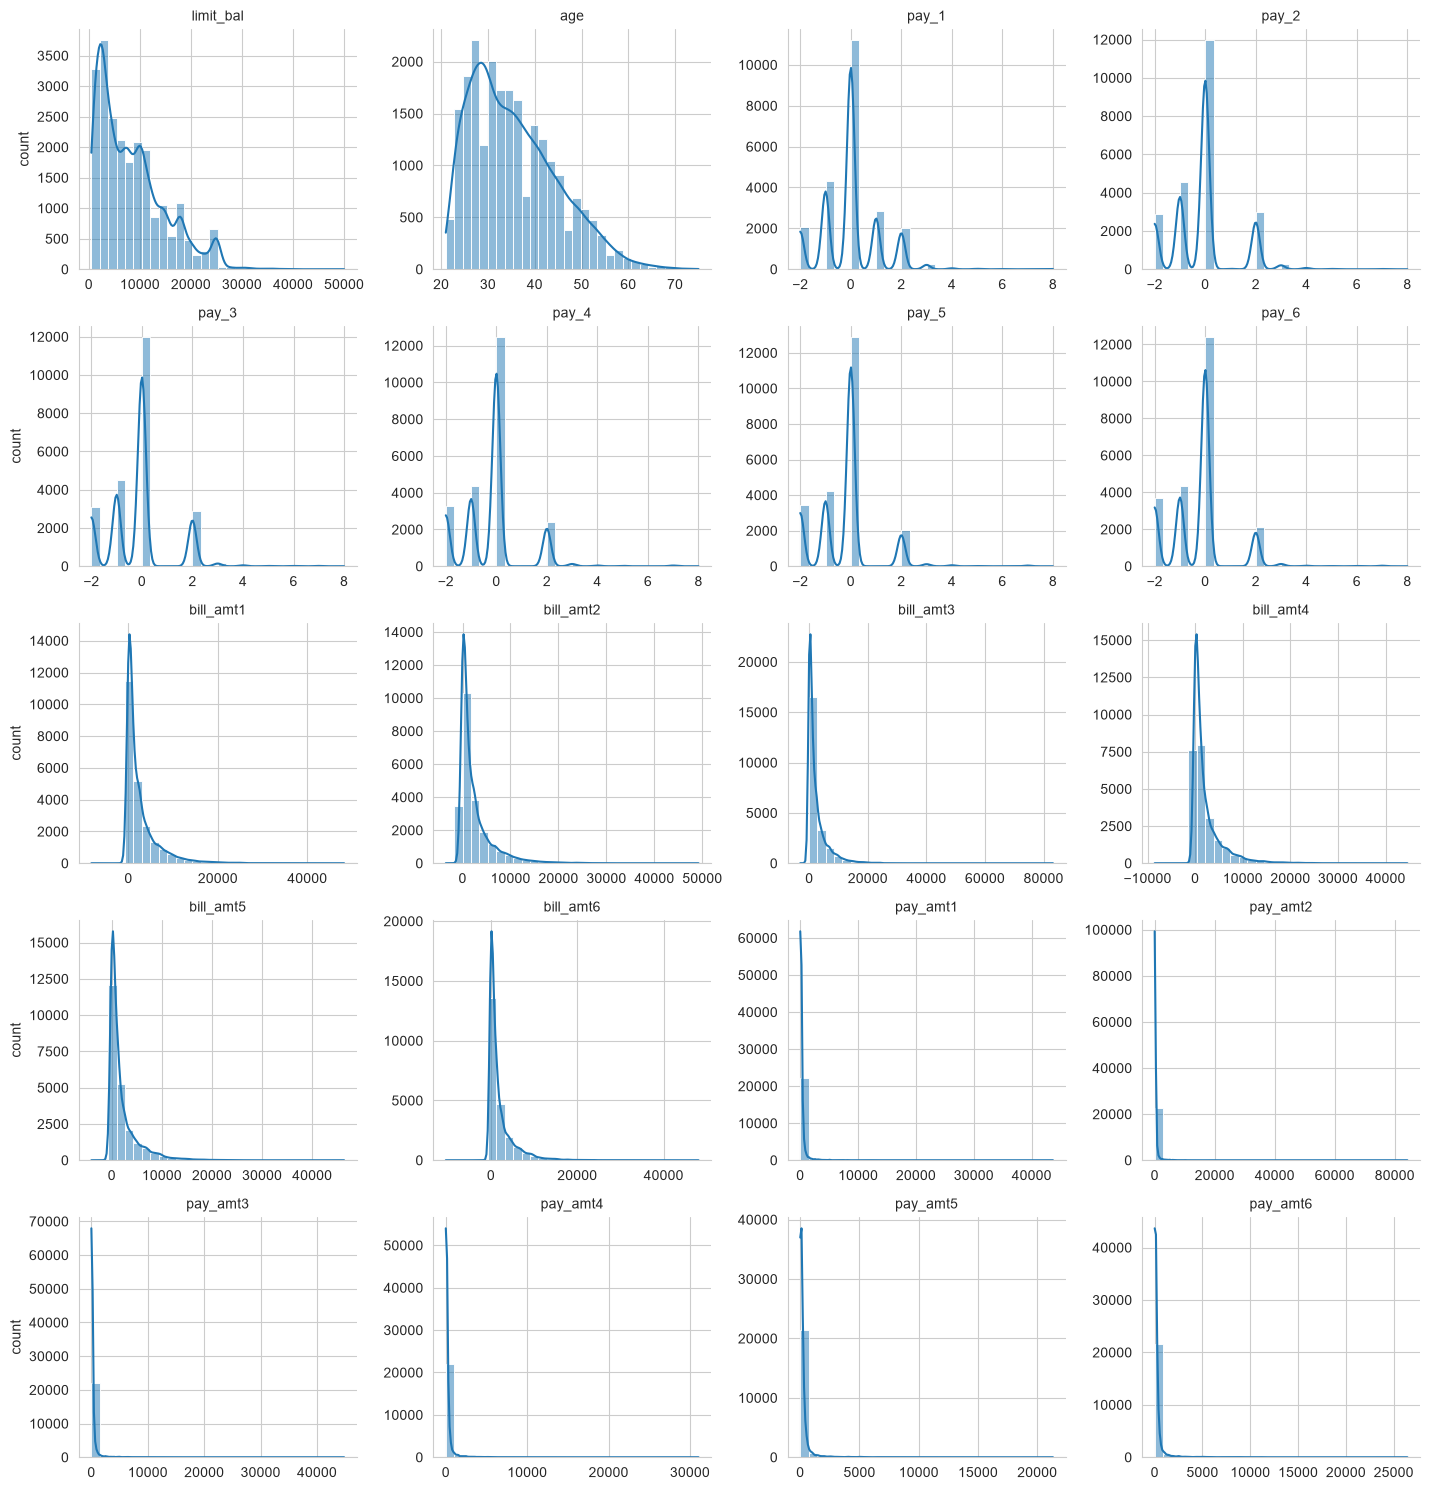

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_numeric = [
    'limit_bal', 'age', 'pay_1', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'
]

# Seaborn grid for distributions
sns.set_style('whitegrid')

g = sns.FacetGrid(
    df[selected_numeric].melt(var_name='feature', value_name='value'),
    col='feature',
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3,
    aspect=1.2
)

g.map_dataframe(sns.histplot, x='value', bins=30, kde=True)

g.set_titles('{col_name}')
g.set_axis_labels('', 'count')
plt.tight_layout()
plt.show()


In [10]:
# Create lagged summary features for the past 6 months
# bill features: bill_amt1..bill_amt6
# payment features: pay_amt1..pay_amt6
# status features: pay_1..pay_6

bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
pay_cols = [f'pay_amt{i}' for i in range(1, 7)]
status_cols = [f'pay_{i}' for i in range(1, 7)]

`# Basic statistics across the last 6 months
for prefix, cols in [('bill', bill_cols), ('pay_amt', pay_cols), ('pay', status_cols)]:
    df[f'{prefix}_last6_mean'] = df[cols].mean(axis=1)
    df[f'{prefix}_last6_std'] = df[cols].std(axis=1, ddof=0)
    df[f'{prefix}_last6_min'] = df[cols].min(axis=1)
    df[f'{prefix}_last6_max'] = df[cols].max(axis=1)
    df[f'{prefix}_last6_p50'] = df[cols].median(axis=1)`

# Late payment rate in the last 6 months: count of status > 0 (delayed payments)
df['late_payment_rate_6m'] = (df[status_cols].gt(0).mean(axis=1))

df['late_payment_count_6m'] = (df[status_cols].gt(0).sum(axis=1))

# Recent momentum / change from most recent month to earlier average
# Example: latest bill vs mean of past 6 months
for bill_col, label in [('bill_amt1', 'recent'), ('bill_amt6', 'oldest')]:
    pass

df['bill_recent_vs_6m_mean'] = df['bill_amt1'] - df['bill_last6_mean']
df['pay_recent_vs_6m_mean'] = df['pay_amt1'] - df['pay_amt_last6_mean']

print(df[[
    'customer_id',
    'bill_last6_mean', 'bill_last6_std', 'bill_last6_max', 'bill_last6_p50',
    # 'pay_amt_last6_mean', 'pay_amt_last6_std', 'pay_amt_last6_max', 'pay_amt_last6_p50',
    # 'late_payment_rate_6m', 'late_payment_count_6m',
    # 'bill_recent_vs_6m_mean', 'pay_recent_vs_6m_mean'
]].head())


   customer_id  bill_last6_mean  bill_last6_std  bill_last6_max  \
0            1      1256.000000      317.762490          1503.0   
1            2      8269.666667      114.957480          8425.0   
2            3       826.500000       69.476015           933.0   
3            4      7149.333333      114.593000          7340.0   
4            5      3861.166667      448.414770          4501.0   

   bill_last6_p50  pay_amt_last6_mean  pay_amt_last6_std  pay_amt_last6_max  \
0          1457.5           68.500000          45.400991              150.0   
1          8287.5          324.166667          35.049568              400.0   
2           812.5          114.833333          44.871731              150.0   
3          7133.5          267.500000          17.914147              307.0   
4          3575.0          157.500000          24.958299              200.0   

   pay_amt_last6_p50  late_payment_rate_6m  late_payment_count_6m  \
0               62.5              0.333333           

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print('XGBoost is not installed in this environment.')

# Convert target to binary 0/1
Y = (df['default_oct'] == 'yes').astype(int)

# Use the same row split for all comparisons
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Lagged features created earlier
lagged_cols = [
    c for c in df.columns
    if c.startswith('bill_last6')
    or c.startswith('pay_amt_last6')
    or c.startswith('pay_last6')
    or c.startswith('late_payment')
    or c.startswith('bill_recent_vs_6m')
    or c.startswith('pay_recent_vs_6m')
]

feature_sets = {
    'baseline_features': [c for c in df.columns if c not in ['customer_id', 'default_oct'] + lagged_cols],
    'with_lagged_features': [c for c in df.columns if c not in ['customer_id', 'default_oct']]
}


def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, proba) if proba is not None else np.nan,
        'log_loss': log_loss(y_test, proba) if proba is not None else np.nan,
    }


results = []
for feature_set_name, feature_cols in feature_sets.items():
    X_train = df.loc[train_idx, feature_cols]
    X_test = df.loc[test_idx, feature_cols]
    y_train = Y.loc[train_idx]
    y_test = Y.loc[test_idx]

    logit = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, random_state=42))
    ])
    results.append({
        'feature_set': feature_set_name,
        'model': 'logistic_regression',
        **evaluate_model(logit, X_train, X_test, y_train, y_test)
    })

    if XGBClassifier is not None:
        xgb = XGBClassifier(
            objective='binary:logistic',
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            eval_metric='logloss'
        )
        results.append({
            'feature_set': feature_set_name,
            'model': 'xgboost',
            **evaluate_model(xgb, X_train, X_test, y_train, y_test)
        })

results_df = pd.DataFrame(results)
print(results_df[['feature_set', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'log_loss']].sort_values(['feature_set', 'model']))

print('\nComparison summary:')
print(results_df.groupby(['feature_set', 'model'])[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'log_loss']].mean())


            feature_set                model  accuracy  precision    recall  \
0     baseline_features  logistic_regression  0.806055   0.706271  0.212091   
1     baseline_features              xgboost  0.815928   0.664729  0.339941   
2  with_lagged_features  logistic_regression  0.808030   0.643777  0.297324   
3  with_lagged_features              xgboost  0.817244   0.662963  0.354807   

         f1   roc_auc  log_loss  
0  0.326220  0.715671  0.467048  
1  0.449836  0.772460  0.433541  
2  0.406780  0.752530  0.445237  
3  0.462234  0.775356  0.432311  

Comparison summary:
                                          accuracy  precision    recall  \
feature_set          model                                                
baseline_features    logistic_regression  0.806055   0.706271  0.212091   
                     xgboost              0.815928   0.664729  0.339941   
with_lagged_features logistic_regression  0.808030   0.643777  0.297324   
                     xgboost          

In [39]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')


def make_balanced_df(df_obj, target_col='default_oct', minority_label=1, random_state=42):
    """Balance a binary classification dataset by downsampling the majority class to the minority size."""

    df = df_obj.dropna(subset=[target_col]).copy()

    majority_label = df[target_col].value_counts().idxmax()
    minority_df = df[df[target_col] == minority_label].copy()
    majority_df = df[df[target_col] == majority_label].copy()

    majority_downsampled = resample(
        majority_df,
        replace=False,
        n_samples=len(minority_df),
        random_state=random_state,
    )

    balanced_df = pd.concat([minority_df, majority_downsampled], ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    print(f"Balanced dataset size: {balanced_df.shape[0]}")
    print(balanced_df[target_col].value_counts().to_dict())
    return balanced_df


# Start from a known-good source and remove rows with missing values before balancing.
if 'default_oct' not in globals().get('df', pd.DataFrame()).columns:
    df = pd.read_csv('train.csv', header=0)

df = df.dropna().copy()
balanced_df = make_balanced_df(df, target_col='default_oct', minority_label='yes', random_state=42)
Y = (balanced_df['default_oct'] == 'yes').astype(int)

print('Balanced dataset class counts:')
print(Y.value_counts().to_dict())
print('Balanced dataset class proportions:')
print(Y.value_counts(normalize=True).to_dict())

# Create lagged summary features for the past 6 months
bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
pay_cols = [f'pay_amt{i}' for i in range(1, 7)]
status_cols = [f'pay_{i}' for i in range(1, 7)]

for prefix, cols in [('bill', bill_cols), ('pay_amt', pay_cols), ('pay', status_cols)]:
    balanced_df[f'{prefix}_last6_mean'] = balanced_df[cols].mean(axis=1)
    balanced_df[f'{prefix}_last6_std'] = balanced_df[cols].std(axis=1, ddof=0)
    balanced_df[f'{prefix}_last6_min'] = balanced_df[cols].min(axis=1)
    balanced_df[f'{prefix}_last6_max'] = balanced_df[cols].max(axis=1)
    balanced_df[f'{prefix}_last6_p50'] = balanced_df[cols].median(axis=1)

balanced_df['late_payment_rate_6m'] = balanced_df[status_cols].gt(0).mean(axis=1)
balanced_df['late_payment_count_6m'] = balanced_df[status_cols].gt(0).sum(axis=1)
balanced_df['bill_recent_vs_6m_mean'] = balanced_df['bill_amt1'] - balanced_df['bill_last6_mean']
balanced_df['pay_recent_vs_6m_mean'] = balanced_df['pay_amt1'] - balanced_df['pay_amt_last6_mean']

lagged_cols = [
    c for c in balanced_df.columns
    if c.startswith('bill_last6')
    or c.startswith('pay_amt_last6')
    or c.startswith('pay_last6')
    or c.startswith('late_payment')
    or c.startswith('bill_recent_vs_6m')
    or c.startswith('pay_recent_vs_6m')
]

feature_sets = {
    'baseline_features': [c for c in balanced_df.columns if c not in ['customer_id', 'default_oct'] + lagged_cols],
    'with_lagged_features': [c for c in balanced_df.columns if c not in ['customer_id', 'default_oct']]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'neg_log_loss']

results = []

for name, cols in feature_sets.items():
    X = balanced_df[cols]

    estimators = [
        ('logistic_regression', LogisticRegression()),
        ('xgboost', XGBClassifier())
    ]

    for estimator_name, estimator in estimators:
        estimator_scores = cross_validate(estimator, X, Y, cv=cv, scoring=scoring)
        results.append({
            'feature_set': name,
            'model': estimator_name,
            'accuracy': estimator_scores['test_accuracy'].mean(),
            'precision': estimator_scores['test_precision'].mean(),
            'recall': estimator_scores['test_recall'].mean(),
            'f1': estimator_scores['test_f1'].mean(),
            'roc_auc': estimator_scores['test_roc_auc'].mean(),
            'log_loss': -estimator_scores['test_neg_log_loss'].mean(),
        })

results_df = pd.DataFrame(results)
print('\nCross-validation summary on balanced dataset:')
print(results_df[['feature_set', 'model', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'log_loss']].sort_values(['feature_set', 'model']))


Balanced dataset size: 10090
{'no': 5045, 'yes': 5045}
Balanced dataset class counts:
{0: 5045, 1: 5045}
Balanced dataset class proportions:
{0: 0.5, 1: 0.5}

Cross-validation summary on balanced dataset:
            feature_set                model  accuracy  precision    recall  \
0     baseline_features  logistic_regression  0.611397   0.591177  0.722299   
1     baseline_features              xgboost  0.679485   0.691839  0.647770   
2  with_lagged_features  logistic_regression  0.644500   0.685887  0.533201   
3  with_lagged_features              xgboost  0.687711   0.699968  0.657086   

         f1   roc_auc  log_loss  
0  0.650150  0.646844  0.666579  
1  0.668953  0.746246  0.629446  
2  0.599730  0.697362  0.650559  
3  0.677847  0.747822  0.633878  


XGBoost confusion matrix (lagged features):
[[699 310]
 [319 690]]


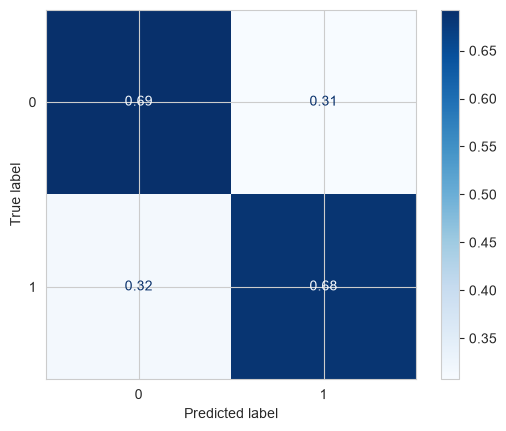

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = balanced_df[feature_sets['with_lagged_features']]
y = (balanced_df['default_oct'] == 'yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print('XGBoost confusion matrix (lagged features):')
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    normalize='true',
    cmap='Blues'
)
plt.show()
